# Bit Coin Analysis (EDA)
v 1.0.0

## Project Overview

This project analyzes historical Bitcoin price data from 2010 to 2026.

Objectives:
- Explore price behavior and volatility patterns
- Analyze the relationship between price movements and trading volume
- Study seasonal patterns in Bitcoin markets
- Examine the characteristics of different price categories
- Calculate the moving averages (SMA/EMA)

## Data Import

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib import cm

In [112]:
bitcoin = pd.read_csv("bitcoin.csv")

## Dataset Overview

In [113]:
bitcoin.head()

,Date,Open,High,Low,Close,Volume,PriceCategory
0,2010-01-01,0.3,0.303428,0.295510,0.3,715.8,Low
1,2010-01-02,0.3,0.304377,0.299459,0.3,2028.3,Low
2,2010-01-03,0.3,0.303736,0.295858,0.3,273.0,Low
3,2010-01-04,0.3,0.303406,0.298489,0.3,1452.0,Low
4,2010-01-05,0.3,0.302715,0.296330,0.3,1002.6,Low


In [114]:
bitcoin.shape

(5883, 7)

In [115]:
bitcoin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5883 entries, 0 to 5882
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           5883 non-null   object 
 1   Open           5883 non-null   float64
 2   High           5883 non-null   float64
 3   Low            5883 non-null   float64
 4   Close          5883 non-null   float64
 5   Volume         5883 non-null   float64
 6   PriceCategory  5883 non-null   object 
dtypes: float64(5), object(2)
memory usage: 321.9+ KB


In [116]:
bitcoin.isnull().sum()

Date             0
Open             0
High             0
Low              0
Close            0
Volume           0
PriceCategory    0
dtype: int64

In [117]:
start_date = bitcoin['Date'].min()
end_date = bitcoin['Date'].max()

print(f"Dataset covers {start_date.date()} to {end_date.date()}")

AttributeError: 'str' object has no attribute 'date'

The dataset spans more than a decade of Bitcoin market activity,
covering multiple market cycles including bull runs and major corrections.

## Feature Engineering

To facilitate time-based and market behavior analysis,
several additional features are created from the original dataset.

These include temporal variables and market behavior indicators.

### Temporal features

These temporal features allow the analysis of seasonal patterns
such as weekday effects, monthly trends and quarterly behavior.

In [118]:
bitcoin['Date'] = pd.to_datetime(bitcoin['Date'])
bitcoin['Year'] = bitcoin['Date'].dt.year
bitcoin['Month'] = bitcoin['Date'].dt.month
bitcoin['Day'] = bitcoin['Date'].dt.day
bitcoin['DayOfWeek'] = bitcoin['Date'].dt.day_name()  # Monday, Tuesday, etc.
bitcoin['Week'] = bitcoin['Date'].dt.isocalendar().week
bitcoin['Quarter'] = bitcoin['Date'].dt.quarter
bitcoin[['Date','Year','Month','DayOfWeek','Quarter']].head()

,Date,Year,Month,DayOfWeek,Quarter
0,2010-01-01,2010,1,Friday,1
1,2010-01-02,2010,1,Saturday,1
2,2010-01-03,2010,1,Sunday,1
3,2010-01-04,2010,1,Monday,1
4,2010-01-05,2010,1,Tuesday,1


### Market behavior features

In [119]:
def complete_bitcoin_analysis(df):
    """
    Complete Bitcoin analysis combining:
    - Returns
    - Volatility (price range)
    - Temporal features
    - Price position
    """
    df_copy = df.copy()
    
    # ===========================================
    # 3. VOLATILITY FEATURES
    # ===========================================
    # Price Range (absolute difference)
    df_copy['PriceRange'] = df_copy['High'] - df_copy['Low']
    
    # Daily volatility as percentage of close
    df_copy['Volatility'] = ((df_copy['High'] - df_copy['Low']) / df_copy['Close']) * 100
    
    # Range relative to open (another perspective)
    df_copy['PriceRange_Pct'] = ((df_copy['High'] - df_copy['Low']) / df_copy['Open']) * 100
    
    # ===========================================
    # 4. PRICE POSITION (where did it close relative to the range)
    # ===========================================
    # Close position in the day's range (0 = at low, 100 = at high)
    # Avoid division by zero
    mask = (df_copy['High'] - df_copy['Low']) != 0
    df_copy['Close_Position'] = np.nan
    df_copy.loc[mask, 'Close_Position'] = ((df_copy.loc[mask, 'Close'] - df_copy.loc[mask, 'Low']) / 
                                           (df_copy.loc[mask, 'High'] - df_copy.loc[mask, 'Low'])) * 100
    
    return df_copy

# Apply the analysis
bitcoin_analyzed = complete_bitcoin_analysis(bitcoin)

# Display the first few rows as a table
bitcoin_analyzed[['Date', 'PriceRange', 'Volatility', 'Close_Position']].head()


,Date,PriceRange,Volatility,Close_Position
0,2010-01-01,0.007919,2.639516,56.706244
1,2010-01-02,0.004917,1.639081,10.995256
2,2010-01-03,0.007878,2.626002,52.579982
3,2010-01-04,0.004916,1.638779,30.724146
4,2010-01-05,0.006385,2.128207,57.478567


## Price Behavior Analysis

This section explores how Bitcoin prices evolve over time and how daily market
behavior can be characterized through several indicators.

The analysis focuses on:

• Daily price movement measured through the high-low range  
• The position of the closing price within the daily range  
• Temporal patterns in price movement across weekdays and months  
• The relationship between trading volume and price fluctuations  

These visualizations help reveal structural patterns in Bitcoin's market
dynamics and provide insight into how price movements are distributed
across different time periods.

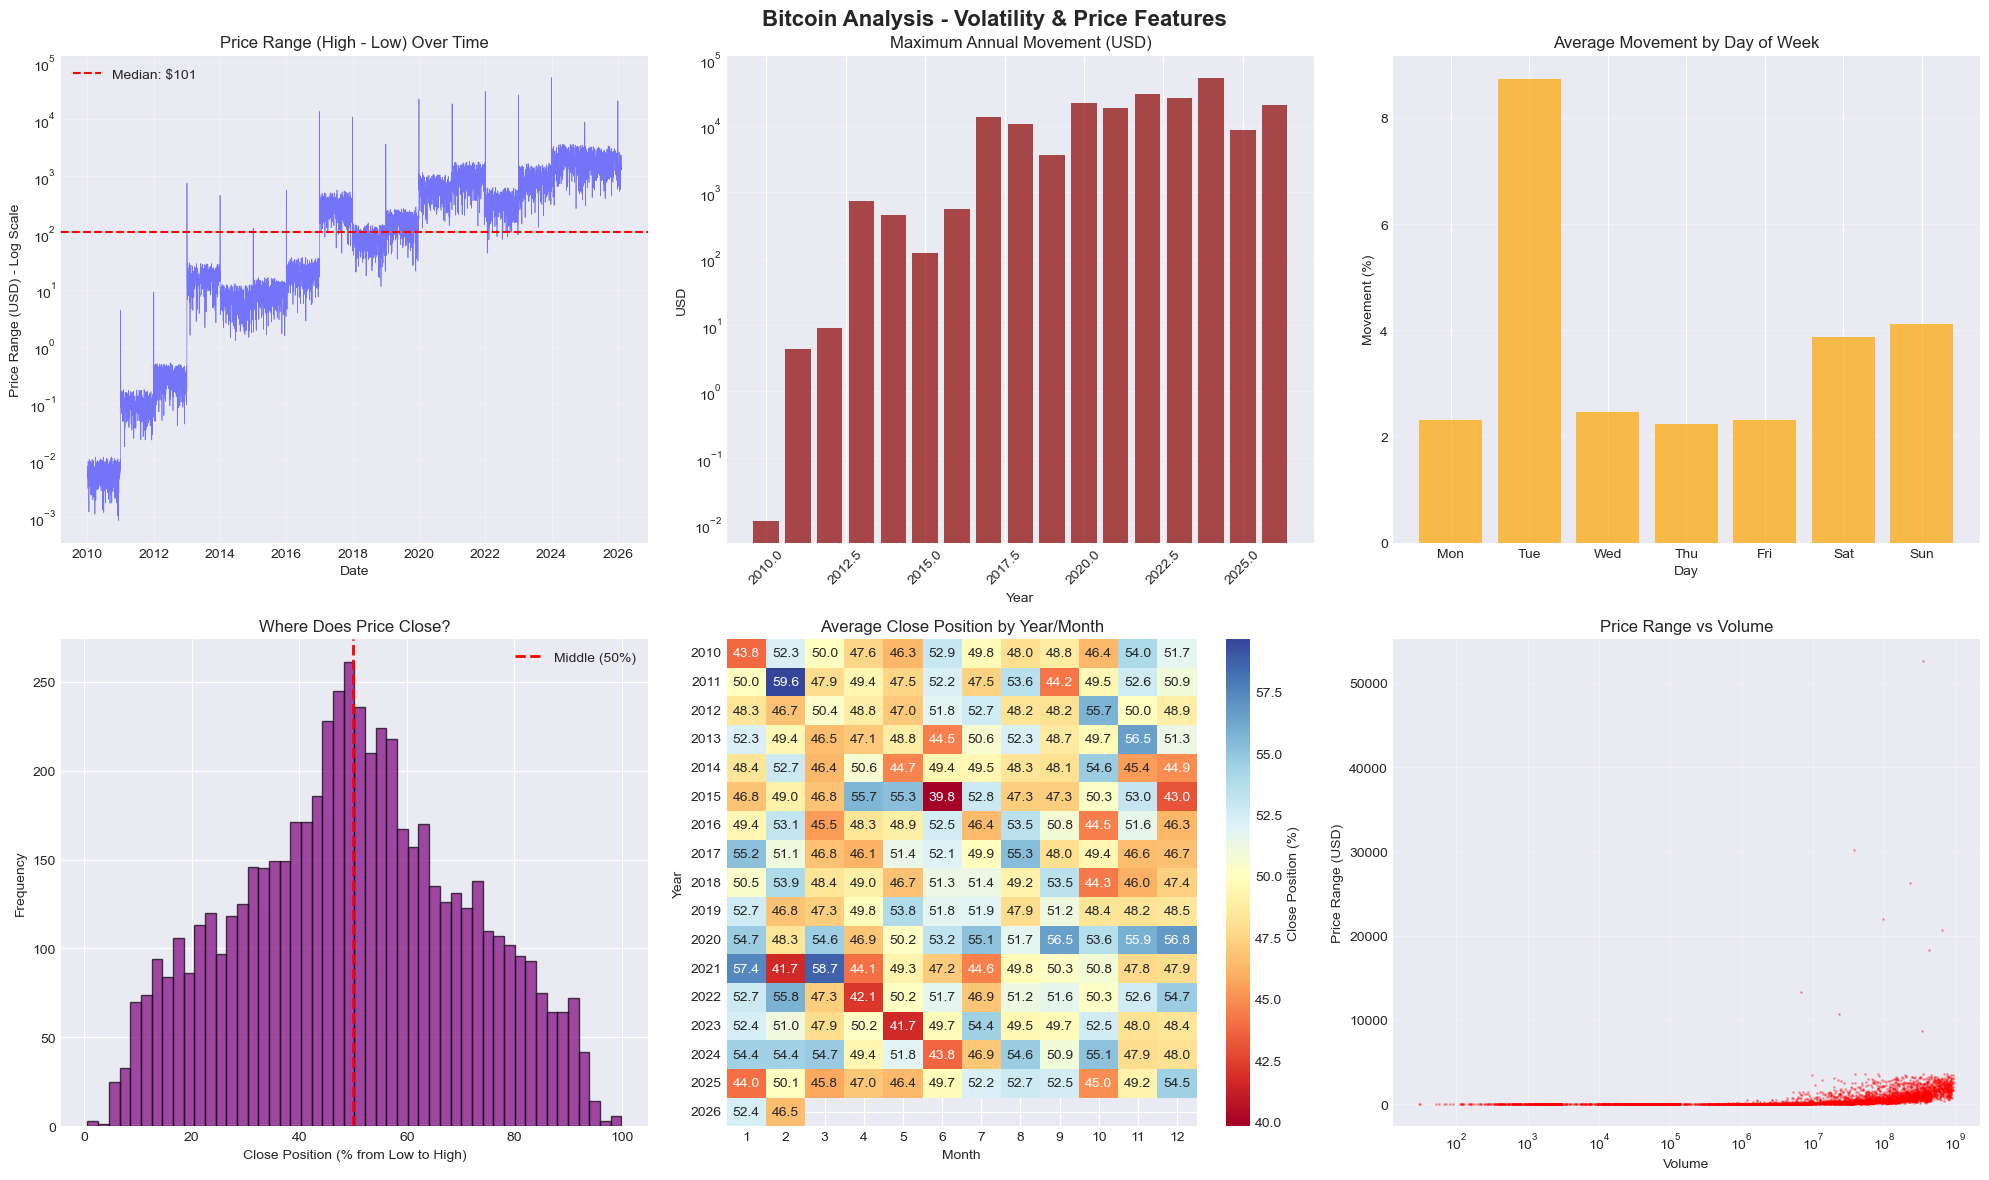

In [120]:
# Create a figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Bitcoin Analysis - Volatility & Price Features', fontsize=16, fontweight='bold')

# ─────────────────────────────────────────────────────────────
#  1: Price Range over time (posición [0,0])
# ─────────────────────────────────────────────────────────────
axes[0, 0].set_yscale('log')
axes[0, 0].plot(bitcoin_analyzed['Date'], bitcoin_analyzed['PriceRange'], 
                alpha=0.5, linewidth=0.5, color='blue')
axes[0, 0].axhline(y=bitcoin_analyzed['PriceRange'].median(), color='red', linestyle='--', 
                   label=f'Median: ${bitcoin_analyzed["PriceRange"].median():.0f}')
axes[0, 0].set_title('Price Range (High - Low) Over Time', fontsize=12)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price Range (USD) - Log Scale')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# ─────────────────────────────────────────────────────────────
#  2: Maximum Annual Movement (posición [0,1])
# ─────────────────────────────────────────────────────────────
max_by_year = bitcoin_analyzed.groupby('Year')['PriceRange'].max()
axes[0, 1].bar(max_by_year.index, max_by_year.values, color='darkred', alpha=0.7)
axes[0, 1].set_title('Maximum Annual Movement (USD)', fontsize=12)
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('USD')
axes[0, 1].set_yscale('log')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# ─────────────────────────────────────────────────────────────
#  3: Movement by Day of Week (posición [0,2])
# ─────────────────────────────────────────────────────────────
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_names_es = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

mov_by_day = [bitcoin_analyzed[bitcoin_analyzed['DayOfWeek'] == day]['PriceRange_Pct'].mean() 
              for day in day_order]
axes[0, 2].bar(day_names_es, mov_by_day, color='orange', alpha=0.7)
axes[0, 2].set_title('Average Movement by Day of Week', fontsize=12)
axes[0, 2].set_xlabel('Day')
axes[0, 2].set_ylabel('Movement (%)')
axes[0, 2].grid(True, alpha=0.3, axis='y')

# ─────────────────────────────────────────────────────────────
#  4: Close Position Distribution (posición [1,0])
# ─────────────────────────────────────────────────────────────
axes[1, 0].hist(bitcoin_analyzed['Close_Position'].dropna(), bins=50, 
                edgecolor='black', alpha=0.7, color='purple')
axes[1, 0].axvline(x=50, color='red', linestyle='--', linewidth=2, label='Middle (50%)')
axes[1, 0].set_title('Where Does Price Close?', fontsize=12)
axes[1, 0].set_xlabel('Close Position (% from Low to High)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# ─────────────────────────────────────────────────────────────
#  5: Close Position Heatmap by Year/Month (posición [1,1])
# ─────────────────────────────────────────────────────────────
pivot_close = bitcoin_analyzed.pivot_table(
    values='Close_Position', 
    index='Year', 
    columns='Month',
    aggfunc='mean'
)
sns.heatmap(pivot_close, annot=True, fmt='.1f', cmap='RdYlBu', center=50, 
            ax=axes[1, 1], cbar_kws={'label': 'Close Position (%)'})
axes[1, 1].set_title('Average Close Position by Year/Month', fontsize=12)
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Year')

# ─────────────────────────────────────────────────────────────
#  6: Price Range vs Volume (posición [1,2])
# ─────────────────────────────────────────────────────────────
axes[1, 2].scatter(bitcoin_analyzed['Volume'], bitcoin_analyzed['PriceRange'], 
                   alpha=0.3, s=1, color='red')
axes[1, 2].set_xlabel('Volume')
axes[1, 2].set_ylabel('Price Range (USD)')
axes[1, 2].set_title('Price Range vs Volume')
axes[1, 2].set_xscale('log')  # Log scale for volume
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 1️⃣ Price Range Over Time
**Question:** How has Bitcoin's daily price range changed?  
- Periods of high volatility appear as spikes above the median.

---

 2️⃣ Maximum Annual Movement
**Question:** Which years had the largest price swings?  
- Logarithmic view highlights the most volatile years.

---

 3️⃣ Average Movement by Day of Week
**Question:** Are some weekdays more volatile?  
- Tuesdays show slightly higher average movements.

---

 4️⃣ Close Position Distribution
**Question:** Where does price usually close within the daily range?  
- Most closes are near the middle, rarely at extremes.

---

 5️⃣ Average Close Position by Year/Month
**Question:** How does closing behavior change seasonally?  
- Heatmap shows trends in higher or lower closes by month/year.

---

 6️⃣ Price Range vs Volume
**Question:** Does trading volume relate to volatility?  
- Higher volume sometimes aligns with larger price swings, but not always.

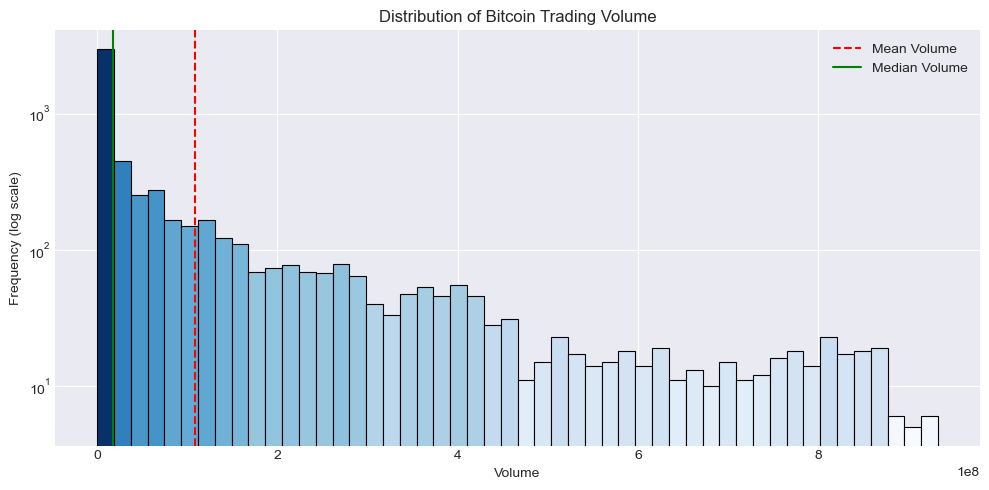

In [121]:

plt.figure(figsize=(10,5))

# Calcular histograma
counts, bins, patches = plt.hist(bitcoin['Volume'], bins=50, edgecolor='black')

# Normalizar usando log de counts para mejor contraste
norm = plt.Normalize(np.log1p(counts).min(), np.log1p(counts).max())

# Aplicar colormap con bordes negros
for count, patch in zip(counts, patches):
    color = cm.Blues(norm(np.log1p(count)))
    patch.set_facecolor(color)
    patch.set_edgecolor('black')   # borde negro
    patch.set_linewidth(0.8)

plt.yscale('log')
plt.axvline(bitcoin['Volume'].mean(), color='red', linestyle='--', label='Mean Volume')
plt.axvline(bitcoin['Volume'].median(), color='green', linestyle='-', label='Median Volume')

plt.title("Distribution of Bitcoin Trading Volume")
plt.xlabel("Volume")
plt.ylabel("Frequency (log scale)")
plt.legend()
plt.tight_layout()
plt.show()

The histogram shows the distribution of daily Bitcoin trading volume.

Most trading days cluster around moderate volume levels, while a smaller number
of days exhibit extremely high trading activity.

The right-skewed distribution suggests that periods of unusually high market
activity occur relatively rarely but can significantly impact the average
trading volume.

The difference between the mean and median volume further highlights the
presence of extreme high-volume trading days, which often coincide with major
price movements in the market.

## Volatility Analysis

Volatility is a defining characteristic of cryptocurrency markets.
In this section we analyze how Bitcoin's daily volatility behaves
across different time periods.

Volatility is measured using the daily price range (High - Low) and
its percentage relative to the closing price.

The following visualizations explore:

• The overall distribution of daily price ranges  
• Average volatility patterns across weekdays  
• The statistical characteristics of volatility in the dataset

In [122]:
bitcoin_analyzed[['PriceRange','Volatility']].describe()

,PriceRange,Volatility
count,5883.000000,5883.000000
mean,486.140001,2.309650
std,1209.523009,5.634973
min,0.000880,0.209104
25%,7.337115,1.512438
50%,101.248532,2.068480
75%,628.319497,2.656443
max,52563.116823,286.978595


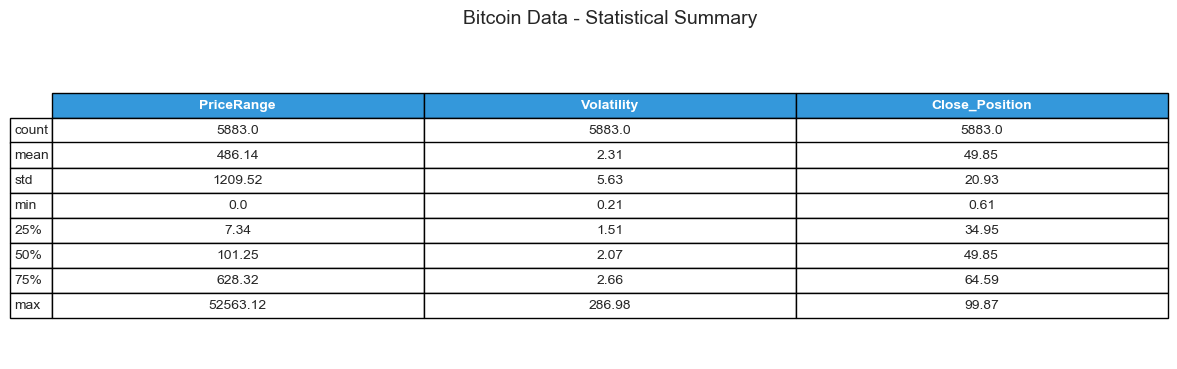

In [123]:
# Create a statistical summary table visualization
fig3, ax3 = plt.subplots(figsize=(12, 4))

# Calculate statistics
stats = bitcoin_analyzed[['PriceRange', 'Volatility', 'Close_Position']].describe().round(2)

# Hide axes
ax3.axis('tight')
ax3.axis('off')

# Create table
table = ax3.table(cellText=stats.values,
                  rowLabels=stats.index,
                  colLabels=stats.columns,
                  cellLoc='center',
                  loc='center',
                  colColours=['#3498db']*3)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Color the header
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_facecolor('#3498db')
        cell.set_text_props(color='white', weight='bold')

ax3.set_title('Bitcoin Data - Statistical Summary', fontsize=14, pad=20)
plt.show()

### Distribution of Daily Bitcoin Volatility

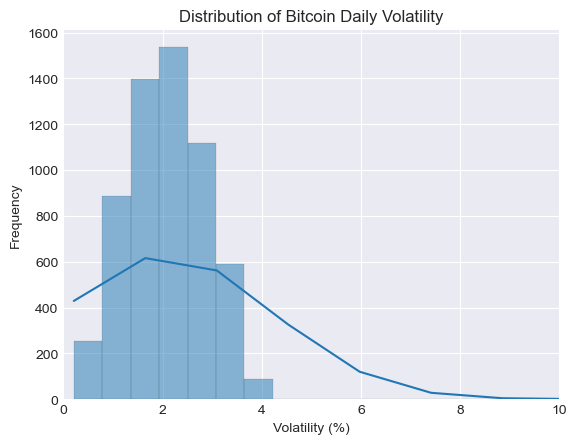

In [124]:
sns.histplot(bitcoin_analyzed['Volatility'], bins=500, kde=True, kde_kws={'bw_adjust': 2})

plt.title("Distribution of Bitcoin Daily Volatility")
plt.xlabel("Volatility (%)")
plt.ylabel("Frequency")
plt.xlim(0, 10)  # limitar eje X

plt.show()

The distribution of daily Bitcoin volatility is highly concentrated at low values,
with most observations falling below 5%. This indicates that although Bitcoin is
known for its volatility, the majority of trading days experience relatively
moderate price movements. Extreme volatility events appear much less frequently.

### Volatility Dynamics Over Time

In [126]:
largest_moves = bitcoin_analyzed.nlargest(5, 'PriceRange')
largest_drops = bitcoin_analyzed.nsmallest(5, 'Close_Position')

largest_moves[['Date','PriceRange','Volatility']]

,Date,PriceRange,Volatility
5113,2024-01-01,52563.116823,56.259838
4383,2022-01-01,30112.221512,181.974446
4748,2023-01-01,26238.918697,62.081630
3652,2020-01-01,22004.792201,75.874094
5844,2026-01-01,20652.392514,29.931004


In [133]:
threshold = bitcoin_analyzed['Volatility'].quantile(0.99)

extreme_days = bitcoin_analyzed[bitcoin_analyzed['Volatility'] >= threshold]

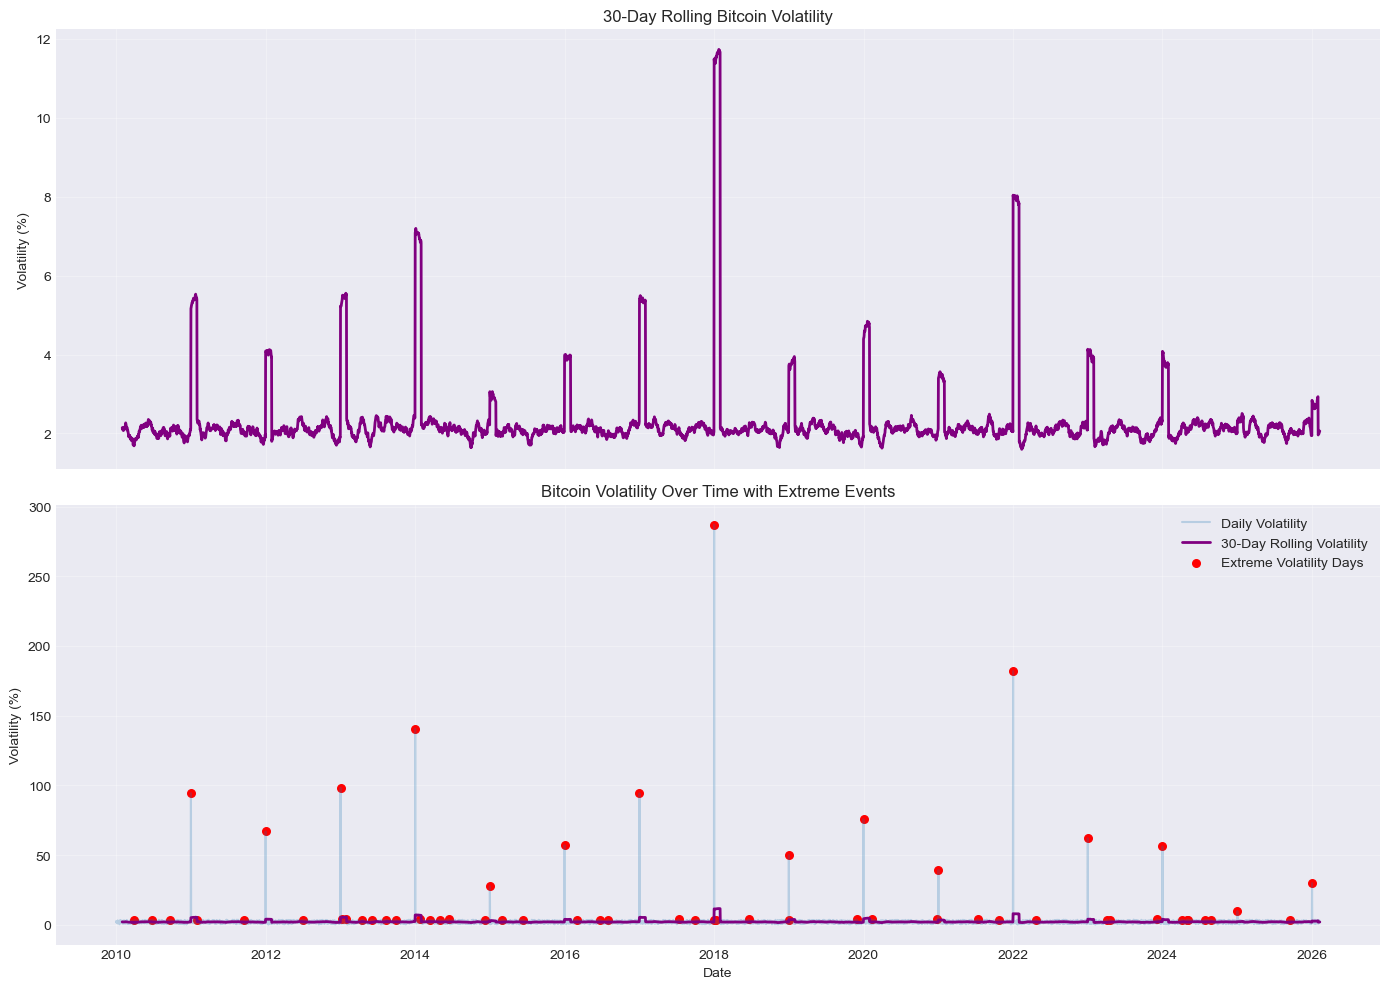

In [146]:
fig, axes = plt.subplots(2, 1, figsize=(14,10), sharex=True)

# ----------------------------------
# 1: Rolling Volatility
# ----------------------------------
axes[0].plot(
    bitcoin_analyzed['Date'],
    bitcoin_analyzed['RollingVolatility'],
    color='purple',
    linewidth=2
)

axes[0].set_title("30-Day Rolling Bitcoin Volatility")
axes[0].set_ylabel("Volatility (%)")
axes[0].grid(alpha=0.3)

# ----------------------------------
# 2: Daily + Rolling + Extreme Days
# ----------------------------------
axes[1].plot(
    bitcoin_analyzed['Date'],
    bitcoin_analyzed['Volatility'],
    alpha=0.25,
    label="Daily Volatility"
)

axes[1].plot(
    bitcoin_analyzed['Date'],
    bitcoin_analyzed['RollingVolatility'],
    linewidth=2,
    color='purple',
    label="30-Day Rolling Volatility"
)

axes[1].scatter(
    extreme_days['Date'],
    extreme_days['Volatility'],
    color='red',
    s=30,
    label="Extreme Volatility Days"
)

axes[1].set_title("Bitcoin Volatility Over Time with Extreme Events")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Volatility (%)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The first chart shows the 30-day rolling volatility, which highlights longer-term
volatility regimes in the Bitcoin market. The second chart combines daily
volatility, the rolling trend, and extreme volatility events (red points),
allowing us to identify periods of unusually large market movements.

### Volatility vs Price Movement by Day of Week

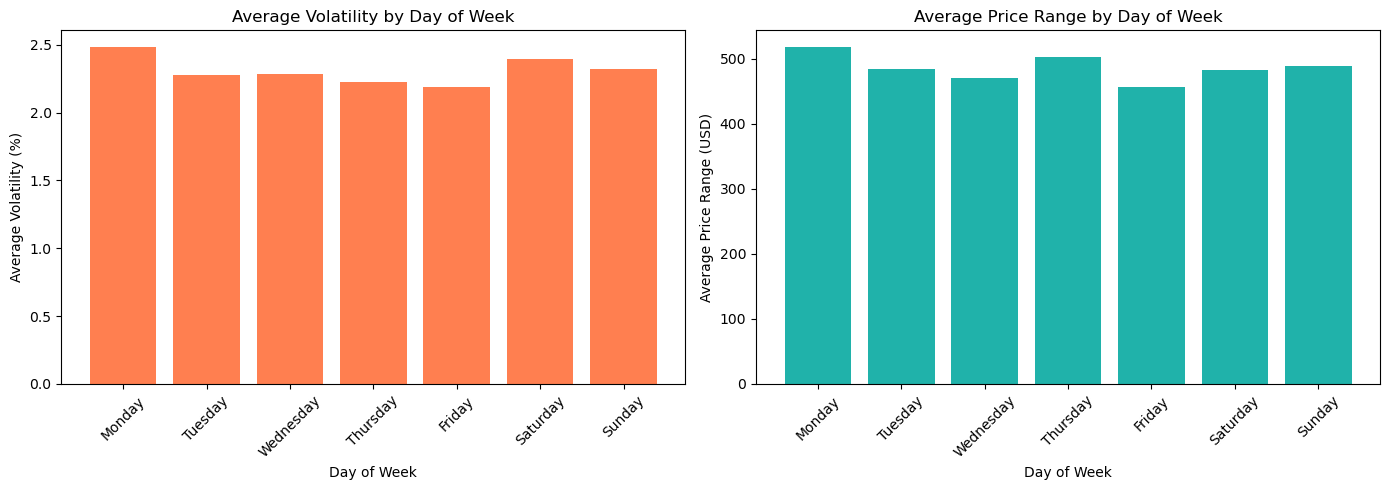

In [28]:
# Analyze volatility by day of week
bitcoin_analyzed['DayOfWeek'] = pd.to_datetime(bitcoin_analyzed['Date']).dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig4, (ax4_1, ax4_2) = plt.subplots(1, 2, figsize=(14, 5))

# Average volatility by day
vol_by_day = bitcoin_analyzed.groupby('DayOfWeek')['Volatility'].mean().reindex(day_order)
ax4_1.bar(vol_by_day.index, vol_by_day.values, color='coral')
ax4_1.set_title('Average Volatility by Day of Week')
ax4_1.set_xlabel('Day of Week')
ax4_1.set_ylabel('Average Volatility (%)')
ax4_1.tick_params(axis='x', rotation=45)

# Average PriceRange by day
range_by_day = bitcoin_analyzed.groupby('DayOfWeek')['PriceRange'].mean().reindex(day_order)
ax4_2.bar(range_by_day.index, range_by_day.values, color='lightseagreen')
ax4_2.set_title('Average Price Range by Day of Week')
ax4_2.set_xlabel('Day of Week')
ax4_2.set_ylabel('Average Price Range (USD)')
ax4_2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

To connect the volatility analysis with price behavior, we examine how both
volatility and the daily price range vary across the days of the week.

This comparison helps identify whether periods of higher volatility also
correspond to larger price movements in the market.

## PriceCategory Analysis

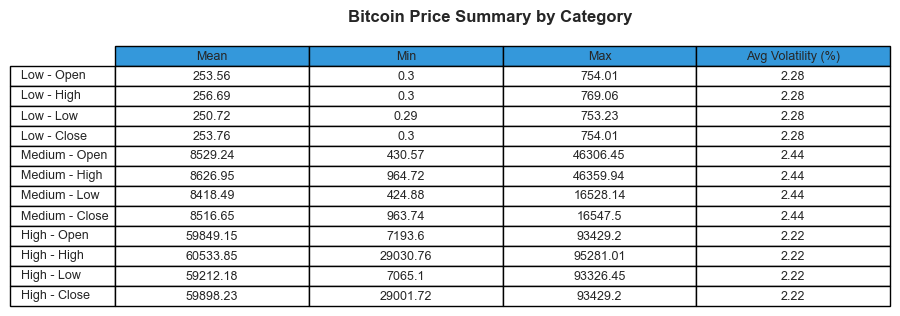

In [141]:

# ─────────────────────────────────────────────────────────────
# COMPACT TABLE FOR ALL PRICE CATEGORIES (portfolio-friendly)
# ─────────────────────────────────────────────────────────────
categories = ['Low', 'Medium', 'High']
price_columns = ['Open', 'High', 'Low', 'Close']


summary_table = pd.DataFrame()

for category in categories:
    category_data = bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == category]
    
    # Seleccionamos solo estadísticas clave
    stats = pd.DataFrame({
        'Mean': category_data[price_columns].mean().round(2),
        'Min': category_data[price_columns].min().round(2),
        'Max': category_data[price_columns].max().round(2),
        'Avg Volatility (%)': [category_data['Volatility'].mean().round(2)]*4
    }, index=price_columns)
    
   
    stats.index = [f"{category} - {col}" for col in stats.index]
    
   
    summary_table = pd.concat([summary_table, stats])

# ─────────────────────────────────────────────────────────────
# PLOT COMPACT TABLE
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=summary_table.values,
                 rowLabels=summary_table.index,
                 colLabels=summary_table.columns,
                 cellLoc='center',
                 loc='center',
                 colColours=['#3498db']*len(summary_table.columns))

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.2)

# Título arriba de la figura
fig.suptitle("Bitcoin Price Summary by Category", fontsize=12, fontweight='bold', y=1.05)

plt.show()

C:\Users\aleja\AppData\Local\Temp\ipykernel_46692\1809444814.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 1].boxplot(price_data, labels=['Low', 'Medium', 'High'], patch_artist=True)
C:\Users\aleja\AppData\Local\Temp\ipykernel_46692\1809444814.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1, 1].boxplot(vol_data, labels=['Low', 'Medium', 'High'], patch_artist=True)


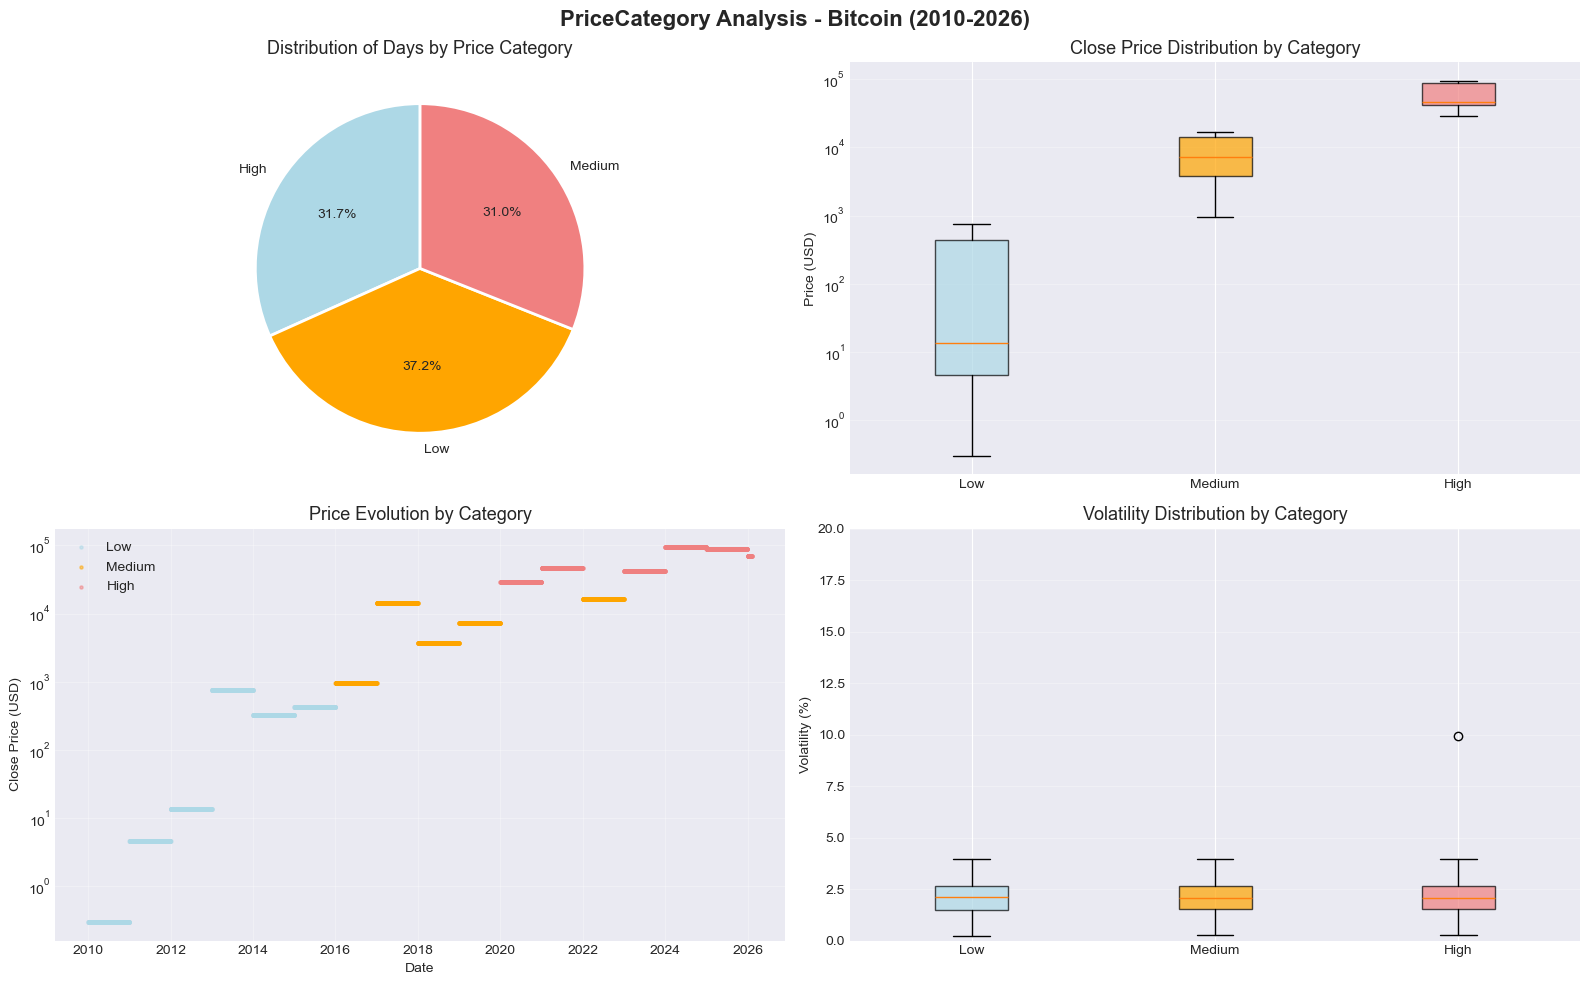

In [138]:

# 3. VISUALIZATIONS
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('PriceCategory Analysis - Bitcoin (2010-2026)', fontsize=16, fontweight='bold')

# Chart 1: Category distribution (pie chart)
colors = ['lightblue', 'orange', 'lightcoral']
axes[0, 0].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
               colors=colors, startangle=90,
               wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0, 0].set_title('Distribution of Days by Price Category', fontsize=13)

# Chart 2: Boxplot of prices by category
price_data = [bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == cat]['Close'] 
              for cat in ['Low', 'Medium', 'High']]
bp = axes[0, 1].boxplot(price_data, labels=['Low', 'Medium', 'High'], patch_artist=True)
for box, color in zip(bp['boxes'], colors):
    box.set_facecolor(color)
    box.set_alpha(0.7)
axes[0, 1].set_title('Close Price Distribution by Category', fontsize=13)
axes[0, 1].set_ylabel('Price (USD)')
axes[0, 1].set_yscale('log')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Chart 3: Temporal evolution by category
colors_map = {'Low': 'lightblue', 'Medium': 'orange', 'High': 'lightcoral'}
for category in ['Low', 'Medium', 'High']:
    cat_data = bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == category]
    axes[1, 0].scatter(cat_data['Date'], cat_data['Close'], 
                       label=category, color=colors_map[category], 
                       alpha=0.5, s=5)
axes[1, 0].set_title('Price Evolution by Category', fontsize=13)
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Close Price (USD)')
axes[1, 0].set_yscale('log')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Chart 4: Volatility by category
vol_data = [bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == cat]['Volatility'] 
            for cat in ['Low', 'Medium', 'High']]
bp2 = axes[1, 1].boxplot(vol_data, labels=['Low', 'Medium', 'High'], patch_artist=True)
for box, color in zip(bp2['boxes'], colors):
    box.set_facecolor(color)
    box.set_alpha(0.7)
axes[1, 1].set_title('Volatility Distribution by Category', fontsize=13)
axes[1, 1].set_ylabel('Volatility (%)')
axes[1, 1].set_ylim(0, 20)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

- **Day distribution:** Most days are `Low`, although `Medium` and `High` are almost equally frequent.  
- **Closing price:** `Low` shows higher and more dispersed prices; `High` is more stable.  
- **Temporal evolution:** High prices predominate in recent years, low prices in the early years.  
- **Volatility:** All three categories have similar volatility (%).

In [49]:
print("\n" + "=" * 60)
print("📊 PRICECATEGORY SUMMARY TABLE")
print("=" * 60)

summary_data = []
for category in ['Low', 'Medium', 'High']:
    cat_data = bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == category]
    
    summary_data.append({
        'Category': category,
        'Days': len(cat_data),
        'Percentage': f"{len(cat_data)/len(bitcoin_analyzed)*100:.1f}%",
        'Price Range': f"${cat_data['Close'].min():.0f} - ${cat_data['Close'].max():.0f}",
        'Mean Close': f"${cat_data['Close'].mean():.0f}",
        'Median Close': f"${cat_data['Close'].median():.0f}",
        'Mean Volatility': f"{cat_data['Volatility'].mean():.1f}%",
        'Period': f"{cat_data['Date'].min().strftime('%Y')}-{cat_data['Date'].max().strftime('%Y')}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


📊 PRICECATEGORY SUMMARY TABLE
Category  Days Percentage     Price Range Mean Close Median Close Mean Volatility    Period
     Low  2191      37.2%       $0 - $754       $254          $14            2.3% 2010-2015
  Medium  1826      31.0%   $964 - $16548      $8517        $7194            2.4% 2016-2022
    High  1866      31.7% $29002 - $93429     $59898       $46306            2.2% 2020-2026


### PriceCategory - Relationship with Other Variables

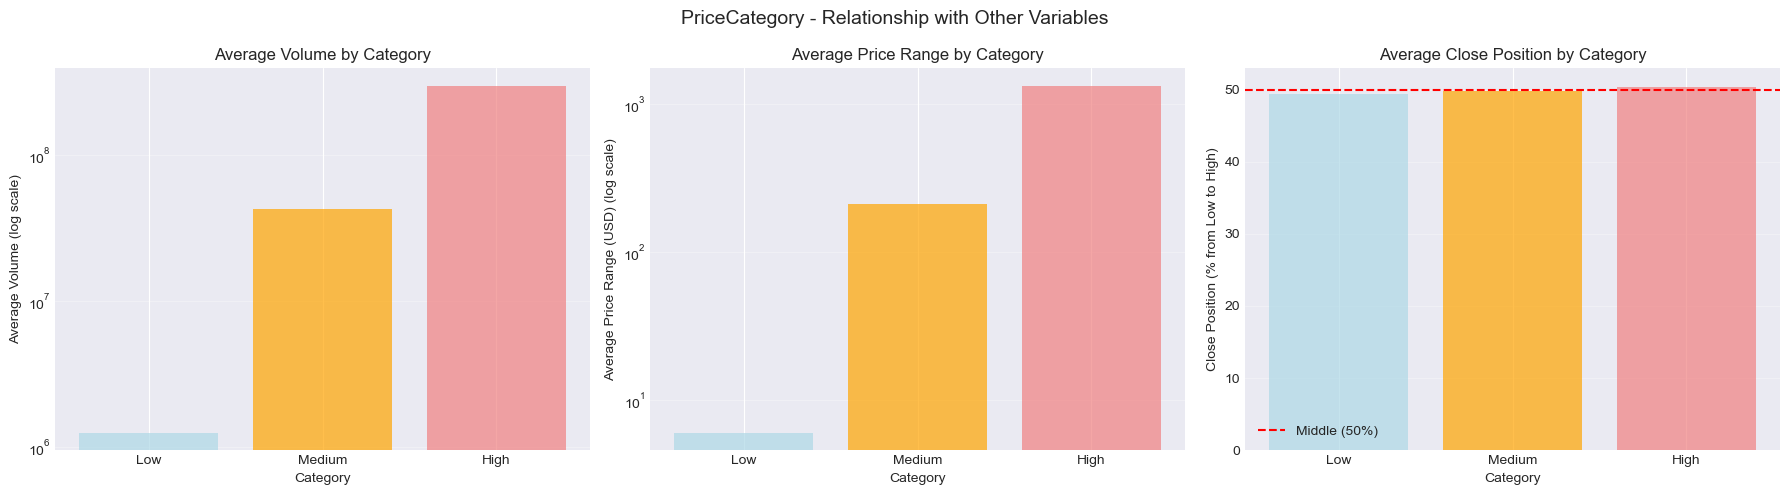

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('PriceCategory - Relationship with Other Variables', fontsize=14)

# 1. Volume by category (con escala log)
for i, category in enumerate(['Low', 'Medium', 'High']):
    vol_mean = bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == category]['Volume'].mean()
    axes[0].bar(i, vol_mean, color=colors[i], alpha=0.7, label=category)
axes[0].set_title('Average Volume by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Average Volume (log scale)')
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(['Low', 'Medium', 'High'])
axes[0].set_yscale('log')  
axes[0].grid(True, alpha=0.3, axis='y')

# 2. PriceRange by category 
for i, category in enumerate(['Low', 'Medium', 'High']):
    range_mean = bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == category]['PriceRange'].mean()
    axes[1].bar(i, range_mean, color=colors[i], alpha=0.7)
axes[1].set_title('Average Price Range by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Average Price Range (USD) (log scale)')
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(['Low', 'Medium', 'High'])
axes[1].set_yscale('log')  
axes[1].grid(True, alpha=0.3, axis='y')

# 3. Close Position by category
for i, category in enumerate(['Low', 'Medium', 'High']):
    pos_mean = bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == category]['Close_Position'].mean()
    axes[2].bar(i, pos_mean, color=colors[i], alpha=0.7)
axes[2].axhline(y=50, color='red', linestyle='--', label='Middle (50%)')
axes[2].set_title('Average Close Position by Category')
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Close Position (% from Low to High)')
axes[2].set_xticks(range(3))
axes[2].set_xticklabels(['Low', 'Medium', 'High'])
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

- **Average Volume:** `High` category has the highest average trading volume, while `Low` has the lowest.
- **Average Price Range:** `High` days show larger daily price ranges, whereas `Low` days are more stable, indicating more intraday fluctuation at high prices.  
- **Average Close Position:** All categories are roughly around the middle (50%) of the daily range, but `High` tends to close slightly higher relative to its daily low, while `Low` closes closer to the low end.

In [56]:
print("\n" + "=" * 60)
print("🔍 PRICECATEGORY INTERPRETATION")
print("=" * 60)

print("""
📌 WHAT DOES EACH CATEGORY MEAN?

• LOW: Low price days (early Bitcoin years, 2010-2013)
   - Very low prices (cents or few dollars)
   - Low USD volatility, same % volatility
   - Low trading volume

• MEDIUM: Growth period (approx. 2014-2020)
   - Intermediate prices ($100 - $10,000)
   - Moderate volatility, same % volatility
   - Developing market

• HIGH: Recent era (2021-2026)
   - High prices (> $10,000)
   - High USD volatility, same % volatility
   - High volume, mature market

📊 DISTRIBUTION SHOULD BE APPROXIMATELY EQUAL
   (33% each) BECAUSE IT WAS CREATED USING QUANTILES.
""")

# Check if distribution is uniform
expected = len(bitcoin_analyzed) / 3
print(f"\n✅ Ideal distribution (33.3% each): {expected:.0f} days per category")
print("📊 Actual distribution:")
for cat, count in category_counts.items():
    diff = ((count - expected) / expected * 100)
    print(f"   {cat}: {count} days ({diff:+.1f}% vs ideal)")


🔍 PRICECATEGORY INTERPRETATION

📌 WHAT DOES EACH CATEGORY MEAN?

• LOW: Low price days (early Bitcoin years, 2010-2013)
   - Very low prices (cents or few dollars)
   - Low USD volatility, same % volatility
   - Low trading volume

• MEDIUM: Growth period (approx. 2014-2020)
   - Intermediate prices ($100 - $10,000)
   - Moderate volatility, same % volatility
   - Developing market

• HIGH: Recent era (2021-2026)
   - High prices (> $10,000)
   - High USD volatility, same % volatility
   - High volume, mature market

📊 DISTRIBUTION SHOULD BE APPROXIMATELY EQUAL
   (33% each) BECAUSE IT WAS CREATED USING QUANTILES.


✅ Ideal distribution (33.3% each): 1961 days per category
📊 Actual distribution:
   High: 1866 days (-4.8% vs ideal)
   Low: 2191 days (+11.7% vs ideal)
   Medium: 1826 days (-6.9% vs ideal)


## Moving Averages (SMA / EMA)

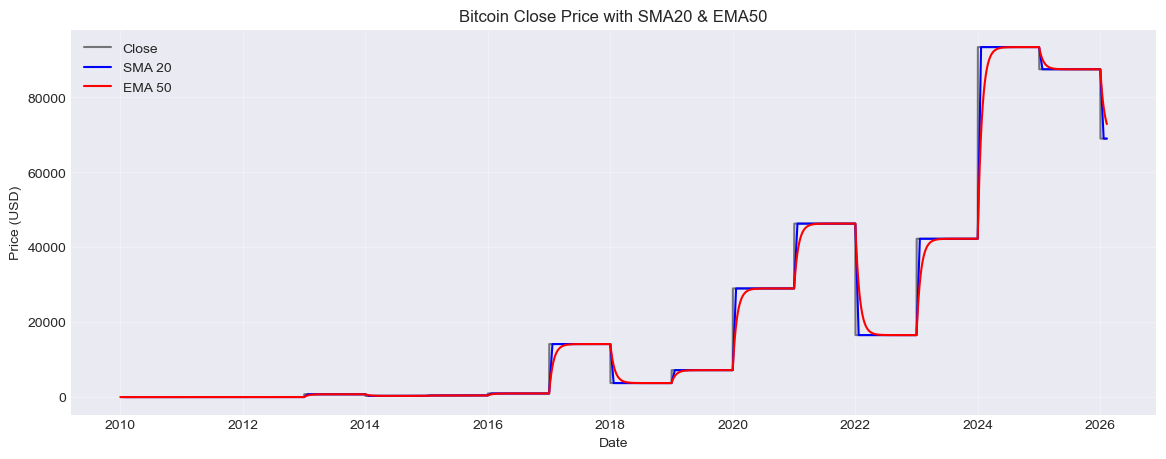

In [148]:
# SMA and EMA
bitcoin_analyzed['SMA20'] = bitcoin_analyzed['Close'].rolling(window=20).mean()
bitcoin_analyzed['EMA50'] = bitcoin_analyzed['Close'].ewm(span=50, adjust=False).mean()

# Plot
plt.figure(figsize=(14,5))
plt.plot(bitcoin_analyzed['Date'], bitcoin_analyzed['Close'], label='Close', color='black', alpha=0.5)
plt.plot(bitcoin_analyzed['Date'], bitcoin_analyzed['SMA20'], label='SMA 20', color='blue')
plt.plot(bitcoin_analyzed['Date'], bitcoin_analyzed['EMA50'], label='EMA 50', color='red')
plt.title('Bitcoin Close Price with SMA20 & EMA50')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

 The chart shows the daily closing price of Bitcoin along with the 20-day simple moving average (SMA20) and the 50-day exponential moving average (EMA50). SMA20 smooths short-term fluctuations, while EMA50 gives more weight to recent prices. Crossovers between these lines can indicate potential trend changes.

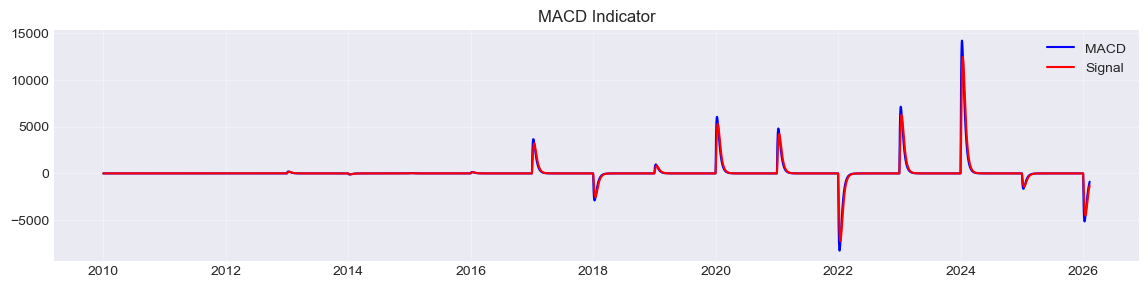

In [150]:
# MACD
ema12 = bitcoin_analyzed['Close'].ewm(span=12, adjust=False).mean()
ema26 = bitcoin_analyzed['Close'].ewm(span=26, adjust=False).mean()
bitcoin_analyzed['MACD'] = ema12 - ema26
bitcoin_analyzed['MACD_signal'] = bitcoin_analyzed['MACD'].ewm(span=9, adjust=False).mean()

# Plot
plt.figure(figsize=(14,3))
plt.plot(bitcoin_analyzed['Date'], bitcoin_analyzed['MACD'], label='MACD', color='blue')
plt.plot(bitcoin_analyzed['Date'], bitcoin_analyzed['MACD_signal'], label='Signal', color='red')
plt.title('MACD Indicator')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

 This chart shows the MACD (Moving Average Convergence Divergence) and its signal line. MACD measures momentum by comparing the 12-day and 26-day EMAs, while the signal line (9-day EMA of MACD) helps identify potential buy or sell signals. Crossovers between MACD and the signal line indicate possible trend changes.